In [2]:
import transbigdata as tbd
import pandas as pd
# 地图匹配包
from leuvenmapmatching.matcher.distance import DistanceMatcher
from leuvenmapmatching.map.inmem import InMemMap
from leuvenmapmatching import visualization as mmviz
 
#读取数据
data = pd.read_csv(r'C:\Users\Mth13\Desktop\project_code\map_matching\gps_features.csv')
# data.columns = ['vid_md5','标准时间','Lng','Lat','gps速度']

ModuleNotFoundError: No module named 'leuvenmapmatching.matcher'; 'leuvenmapmatching' is not a package

C:\Users\Mth13\AppData\Local\Temp\ipykernel_21748\646883236.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  edges['lon'] = edges.centroid.x
C:\Users\Mth13\AppData\Local\Temp\ipykernel_21748\646883236.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  edges['lat'] = edges.centroid.y


<Axes: >

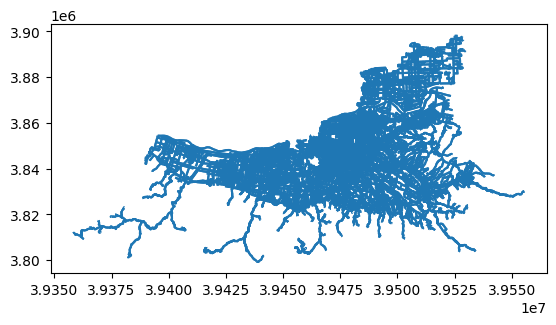

In [ ]:
import osmnx as ox
G = ox.load_graphml(r'C:\\Users\\Mth13\\Desktop\\project_code\\map_matching\\xi_an.graphml')
nodes, edges = ox.graph_to_gdfs(G, nodes=True, edges=True)
edges['lon'] = edges.centroid.x
edges['lat'] = edges.centroid.y

# 转换路网的坐标系
G_p = ox.project_graph(G, to_crs=2416)
nodes_p, edges_p = ox.graph_to_gdfs(G_p, nodes=True, edges=True)


edges_p.plot()

In [3]:
# 将路网转换为网络
map_con = InMemMap(name='pNEUMA', use_latlon=False, use_rtree=True, index_edges=True)
 
# 构建网络
for node_id, row in nodes_p.iterrows():
    map_con.add_node(node_id, (row['y'], row['x']))
for node_id_1, node_id_2, _ in G_p.edges:
    map_con.add_edge(node_id_1, node_id_2)

c:\Users\Mth13\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyproj\crs\crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


(<Figure size 2000x1000.62 with 1 Axes>, <Axes: xlabel='X', ylabel='Y'>)

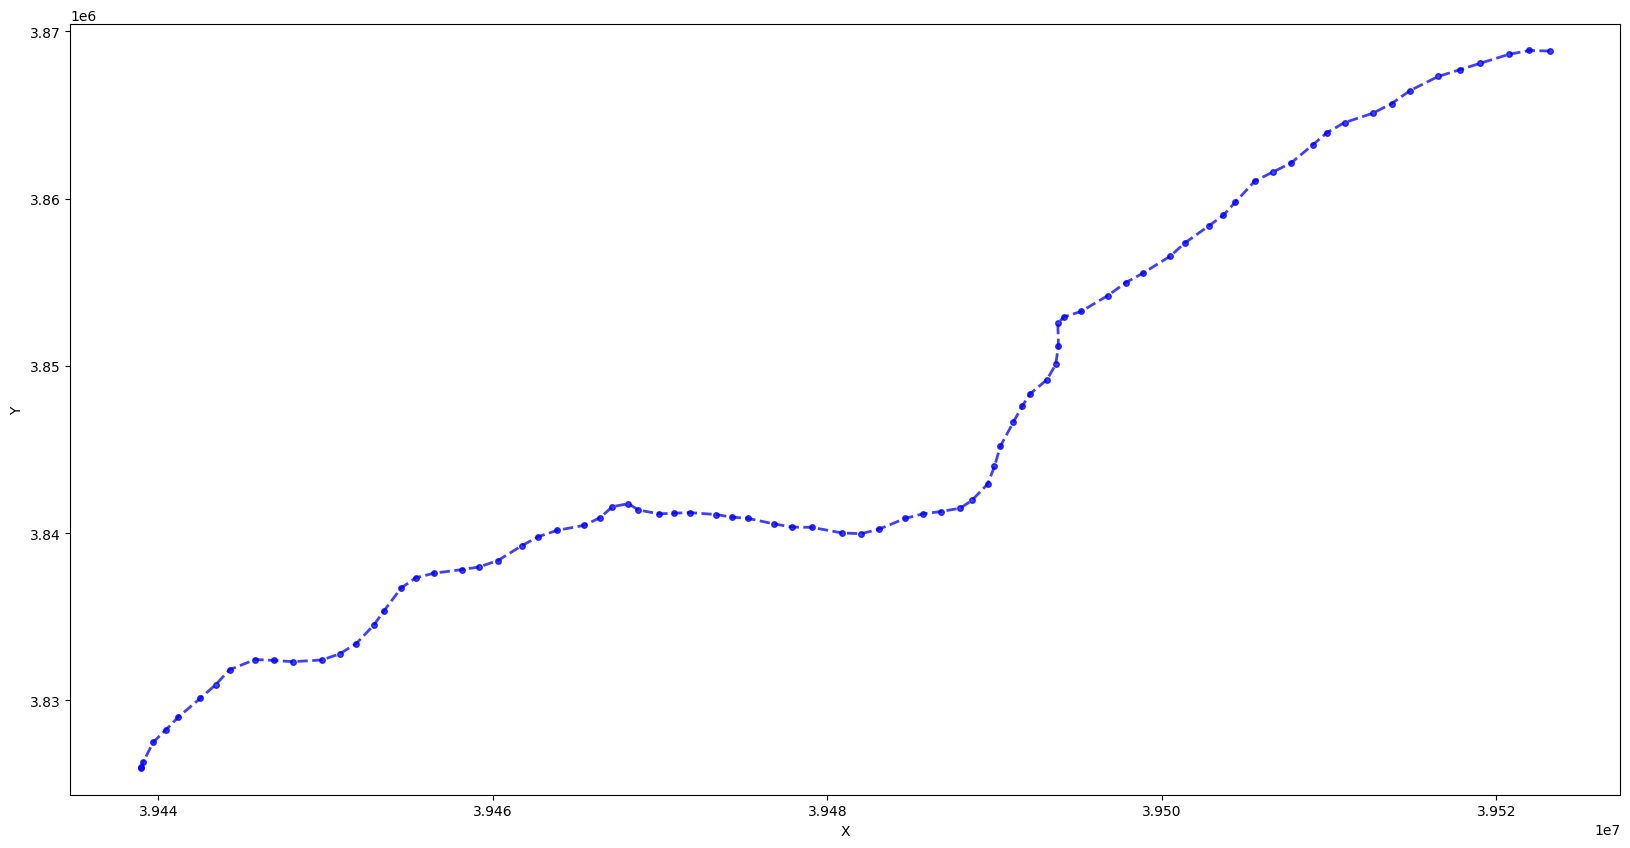

In [5]:
#用transbigdata提取出行轨迹
import geopandas as gpd
tmp_gdf = data[data['vid_md5'] == '002c13314f5da96ea00b1b32cbd0a27f'].sort_values(by = '标准时间')
#轨迹增密
# tmp_gdf = tbd.traj_densify(tmp_gdf,col = ['ID', 'Time', 'Lng', 'Lat'],timegap = 15)
#转换轨迹的坐标系为地理坐标系
tmp_gdf['geometry'] = gpd.points_from_xy(tmp_gdf['Lng'],tmp_gdf['Lat'])
tmp_gdf = gpd.GeoDataFrame(tmp_gdf)
tmp_gdf.crs = {'init':'epsg:4326'}
tmp_gdf = tmp_gdf.to_crs(2416)
#获得轨迹点
path = list(zip(tmp_gdf.geometry.y, tmp_gdf.geometry.x))
#构建地图匹配工具
matcher = DistanceMatcher(map_con, 
                          max_dist=500, 
                          max_dist_init=170, 
                          min_prob_norm=0.0001,
                        non_emitting_length_factor=0.95,
                        obs_noise=50, 
                          obs_noise_ne=50,
                              dist_noise=50,
                              max_lattice_width=20,
                              non_emitting_states=True)
#进行地图匹配
states, _ = matcher.match(path, unique=False)
#绘制底图匹配结果
mmviz.plot_map(map_con, matcher=matcher,
               show_labels=False, show_matching=True, show_graph=False,
               filename=None)

C:\Users\Mth13\AppData\Local\Temp\ipykernel_15804\1517980389.py:7: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  pathgdf.plot()
c:\Users\Mth13\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyproj\crs\crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


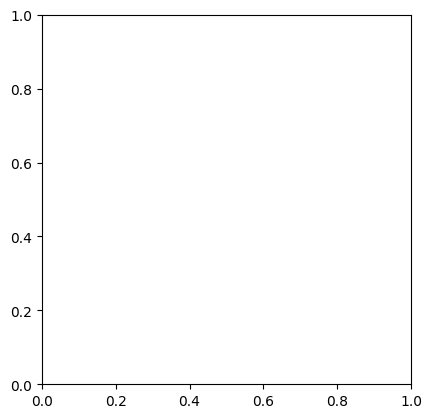

In [14]:
#获取地图匹配的路径geodataframe
pathdf = pd.DataFrame(matcher.path_pred_onlynodes,columns = ['u'])
pathdf['v'] = pathdf['u'].shift(-1)
pathdf = pathdf[-pathdf['v'].isnull()]
pathgdf = pd.merge(pathdf,edges_p.reset_index())
pathgdf = gpd.GeoDataFrame(pathgdf)
pathgdf.plot()
pathgdf.crs = {'init':'epsg:2416'}
pathgdf_4326 = pathgdf.to_crs(4326)

In [ ]:
#与路网一起可视化
import matplotlib as mpl
import matplotlib.pyplot as plt
 
fig     = plt.figure(1,(8,8),dpi = 100)    
ax      = plt.subplot(111)
plt.sca(ax)
fig.tight_layout(rect = (0.05,0.1,1,0.9))
#设定可视化边界
bounds = pathgdf_4326.unary_union.bounds
gap = 0.003
bounds = [bounds[0]-gap,bounds[1]-gap,bounds[2]+gap,bounds[3]+gap]
#绘制匹配的路径
pathgdf_4326.plot(ax = ax,zorder = 1)
#绘制底图路网
tbd.clean_outofbounds(edges,bounds,col = ['lon','lat']).plot(ax = ax,color = '#333',lw = 0.1)
#绘制GPS点
tmp_gdf.to_crs(4326).plot(ax = ax,color = 'r',markersize = 5,zorder = 2)
 
plt.axis('off')
plt.xlim(bounds[0],bounds[2])
plt.ylim(bounds[1],bounds[3])
plt.show()